In [1]:
from PIL import Image
from torchvision import transforms

img = Image.open("cat.png").convert("RGB")

resize = transforms.Resize((224,224))
img = resize(img)

tensor = transforms.ToTensor()(img)

print("Tensor shape:", tensor.shape)
print("First pixel before normalization:")
print(tensor[:,0,0])

normalized = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)(tensor)

print("\nFirst pixel after normalization:")
print(normalized[:,0,0])

Tensor shape: torch.Size([3, 224, 224])
First pixel before normalization:
tensor([0.9804, 0.9765, 0.9725])

First pixel after normalization:
tensor([2.1633, 2.3235, 2.5180])


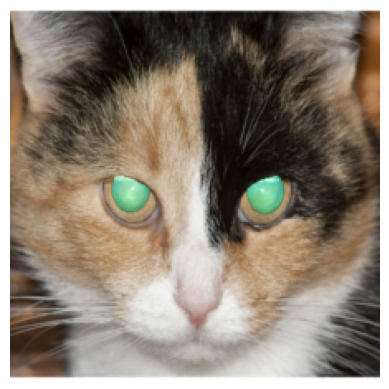

In [2]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import ToPILImage
import matplotlib.pyplot as plt
import torch

# Original image
img = Image.open("cat.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

tensor = transform(img)

# Undo normalization
mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

tensor = tensor * std + mean

# Convert back to image
img_back = ToPILImage()(tensor)

plt.imshow(img_back)
plt.axis("off")
plt.show()